In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd

import config
import estimation

import figures
figures.setup()

In [2]:
panel_df = pd.read_csv(config.WORK / 'panel_narrow.csv')
pair = pd.read_csv(config.WORK / 'pair_panel.csv')
observed = float(estimation.cluster_fit(pair, estimation.MAIN).params['post'])
print(f'observed: {observed:.4f}')

observed: -0.2096


In [3]:
boot = estimation.bootstrap(pair)
perm = estimation.randomization_inference(pair)
pd.DataFrame([
    estimation.describe_draws(boot, observed, 'cluster bootstrap'),
    estimation.describe_draws(perm, observed, 'randomization inference', centre='zero'),
]).round(4)

,spec,coef,se,lo,hi,p,null_distribution,draws
0,cluster bootstrap,-0.2096,0.1286,-0.4612,0.0453,0.1111,False,999
1,randomization inference,-0.2096,0.0693,-0.3006,-0.0302,0.2505,True,2000


saved randomization_inference.pdf and randomization_inference.png


(<Figure size 610x335.5 with 1 Axes>,
 <Axes: xlabel='Coefficient under permuted treatment timing', ylabel='Permutations'>)

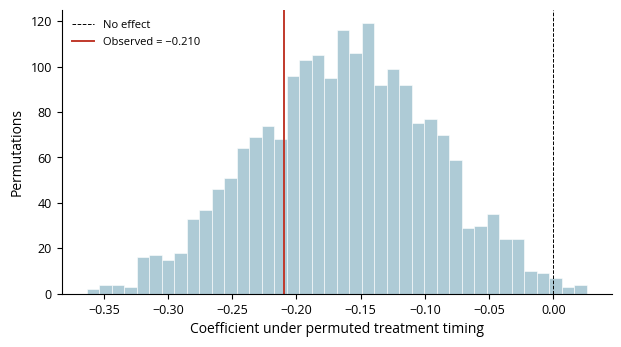

In [4]:
figures.permutation(perm, observed)

In [5]:
windows = estimation.window_sensitivity(pair)
windows.round(4)

,spec,coef,se,p,n
0,rel_year within +/-5,0.0141,0.1297,0.9135,110
1,rel_year within +/-8,-0.0503,0.1589,0.7517,151
2,rel_year within +/-12,-0.1458,0.1523,0.3384,198
3,full panel,-0.2096,0.1350,0.1206,363


In [6]:
bright = estimation.brightness_threshold(pair)
bright.round(4)

,spec,coef,se,p,n,groups
0,dimmest side above 0.0,-0.2096,0.1350,0.1206,363,11
1,dimmest side above 0.01,-0.2347,0.1756,0.1814,264,8
2,dimmest side above 0.05,-0.2347,0.1756,0.1814,264,8
3,dimmest side above 0.1,-0.2347,0.1756,0.1814,264,8


In [7]:
offsets = estimation.offset_sensitivity(panel_df)
offsets.round(4)

pair panel: 363 group-years, 11 groups
pair panel: 363 group-years, 11 groups
pair panel: 363 group-years, 11 groups
pair panel: 363 group-years, 11 groups


,spec,coef,se,p,n
0,offset c = 0.001,-0.3027,0.2482,0.2226,363
1,offset c = 0.01,-0.2096,0.1350,0.1206,363
2,offset c = 0.1,-0.1394,0.0666,0.0363,363
3,offset c = 1.0,-0.0703,0.0331,0.0337,363


In [8]:
windows.to_csv(config.OUT / "window_sensitivity.csv", index=False)
bright.to_csv(config.OUT / "brightness_threshold.csv", index=False)
offsets.to_csv(config.OUT / "offset_sensitivity.csv", index=False)
print("saved")

saved


In [9]:
pd.DataFrame([
    estimation.describe_draws(boot, observed, 'cluster bootstrap'),
    estimation.describe_draws(perm, observed, 'randomization inference', centre='zero'),
]).to_csv(config.OUT / "inference.csv", index=False)
print("saved")

saved


In [10]:
spells = estimation.programme_spells(panel_df)
spells.to_csv(config.OUT / "programme_spells.csv", index=False)
spells

,G1ID,country,name,n_spells,spells
0,124,CG,Bambundu,2,"2003-2005, 2010-2012"
1,173,ET,Berta,4,"1993, 1997, 1999, 2001-2004"
2,224,CM,Bute,2,"1998-2004, 2006-2008"
3,321,CD,Dago,5,"1996-1998, 2000-2003, 2005, 2008, 2015-2017"
4,503,CM,Jukun and Idoma,2,"1998-2004, 2006-2008"
5,574,ET,Koma,4,"1993, 1997, 1999, 2001-2004"
6,685,CM,"Mandara (incl. Matakam, Gidar)",2,"1998-2004, 2006-2008"
7,1095,CM,Tikar,2,"1998-2004, 2006-2008"
8,1101,CM,"Tiv (incl. Ekoi, Boki, Jarawas)",2,"1998-2004, 2006-2008"
9,1192,ZA,"Waluchazi (incl. Waluimbe, Wambundu)",4,"1996-1997, 1999-2002, 2005-2007, 2009-2011"


In [11]:
pair_a = estimation.add_active(pair, panel_df)
onoff = estimation.on_off_specifications(pair_a)
onoff.to_csv(config.OUT / "on_off.csv", index=False)
onoff.round(4)

,spec,coef,se,p,n
0,active programme,0.1202,0.1445,0.4056,363
1,"post entry, no active programme",-0.2737,0.1613,0.0897,363
2,additional effect while active,0.1792,0.1634,0.2728,363
3,entry (34 events),0.1076,0.1299,0.4075,352
4,exit (34 events),0.0022,0.0692,0.9746,352


In [12]:
for formula, term in [("gap ~ active + C(G1ID)", "active"),
                      ("gap ~ post + active + C(G1ID)", "post"),
                      ("gap ~ post + active + C(G1ID)", "active"),
                      ("d_gap ~ entry + exit + C(G1ID)", "entry"),
                      ("d_gap ~ entry + exit + C(G1ID)", "exit")]:
    data = pair_a.dropna(subset=["d_gap"]) if formula.startswith("d_gap") else pair_a
    d = estimation.bootstrap(data, formula=formula, term=term)
    lo, hi = np.percentile(d, [2.5, 97.5])
    print(f"{term:>7}: SE {d.std(ddof=1):.4f}  CI [{lo:.3f}, {hi:.3f}]")

 active: SE 0.1386  CI [-0.166, 0.378]
   post: SE 0.1523  CI [-0.551, 0.037]
 active: SE 0.1557  CI [-0.145, 0.460]
  entry: SE 0.1295  CI [-0.134, 0.368]
   exit: SE 0.0690  CI [-0.120, 0.149]


In [13]:
per_period, agg = estimation.did_m(pair_a)
draws = estimation.did_m_bootstrap(pair_a)
lo, hi = np.percentile(draws, [2.5, 97.5])

pl_period, pl_agg = estimation.did_m(pair_a, placebo=True)
pl_draws = estimation.did_m_bootstrap(pair_a, placebo=True)
pl_lo, pl_hi = np.percentile(pl_draws, [2.5, 97.5])

print(f"DID_M          {agg:+.4f}   SE {draws.std(ddof=1):.4f}   "
      f"CI [{lo:.3f}, {hi:.3f}]   draws {len(draws)}")
print(f"DID_M placebo  {pl_agg:+.4f}   SE {pl_draws.std(ddof=1):.4f}   "
      f"CI [{pl_lo:.3f}, {pl_hi:.3f}]")
print()

by_type = (per_period.groupby("type")
           .apply(lambda g: pd.Series({
               "cells": len(g),
               "switchers": g["switchers"].sum(),
               "effect": (g["effect"] * g["switchers"]).sum() / g["switchers"].sum()}),
                  include_groups=False))
print(by_type.round(4).to_string())
print()
print(per_period.round(4).to_string(index=False))

per_period.to_csv(config.OUT / "did_m_by_period.csv", index=False)
pd.DataFrame([
    {"spec": "DID_M", "coef": agg, "se": float(draws.std(ddof=1)),
     "lo": float(lo), "hi": float(hi), "draws": len(draws)},
    {"spec": "DID_M placebo", "coef": pl_agg, "se": float(pl_draws.std(ddof=1)),
     "lo": float(pl_lo), "hi": float(pl_hi), "draws": len(pl_draws)},
]).to_csv(config.OUT / "did_m.csv", index=False)

DID_M          +0.0911   SE 0.1513   CI [-0.125, 0.468]   draws 999
DID_M placebo  -0.2912   SE 0.1462   CI [-0.536, 0.028]

            cells  switchers  effect
type                                
switch off    9.0       22.0 -0.0244
switch on    12.0       30.0  0.1758

 year       type  switchers  stayers  effect
 1993  switch on          2        9  0.1754
 1996  switch on          3        8  0.1954
 1997  switch on          2        6  0.1289
 1998  switch on          5        1 -0.4522
 1998 switch off          3        2 -0.0049
 1999  switch on          3        1  0.1198
 1999 switch off          2        5  0.2395
 2000  switch on          2        1  0.0000
 2000 switch off          2        6  0.1695
 2001  switch on          2        1  0.0634
 2003 switch off          1        9  0.2604
 2004 switch off          2        8 -0.5931
 2005 switch off          7        1 -0.1582
 2006  switch on          5        2  0.8392
 2006 switch off          3        1  0.0838
 2008 

In [14]:
w = estimation.twfe_weights(pair_a)
neg = w[w["weight"] < 0]
print(f"treated group-years:      {len(w)}")
print(f"negative weights:         {len(neg)} ({100 * len(neg) / len(w):.1f}%)")
print(f"sum of negative weights:  {neg['weight'].sum():+.4f}")
print(f"sum of positive weights:  {w.loc[w['weight'] > 0, 'weight'].sum():+.4f}")
print(f"weight range:             [{w['weight'].min():+.4f}, {w['weight'].max():+.4f}]")
w.to_csv(config.OUT / "twfe_weights.csv", index=False)

treated group-years:      106
negative weights:         0 (0.0%)
sum of negative weights:  +0.0000
sum of positive weights:  +1.0000
weight range:             [+0.0005, +0.0271]


In [15]:
areas = pd.read_csv(config.WORK / "buffer_areas.csv")
panels = {name: pd.read_csv(config.WORK / f"panel_{name}.csv")
          for name in ["narrow", "eff", "broad"]}
robust = estimation.robustness_table(panels, pair, buffer_areas=areas)
robust.to_csv(config.OUT / "robustness.csv", index=False)
robust.round(4)

pair panel: 363 group-years, 11 groups
pair panel: 132 group-years, 4 groups


,spec,coef,se,p,n,groups
0,baseline (narrow definition),-0.2096,0.1350,0.1206,363,11
1,SAP: narrow plus EFF,-0.2096,0.1350,0.1206,363,11
2,SAP: all IMF arrangements,0.0915,0.2076,0.6595,132,4
3,dimmest side above 0.01,-0.2347,0.1756,0.1814,264,8
4,panel restricted to 1992-2013,-0.1447,0.1594,0.3638,242,11
5,area ratio at most 5:1,-0.1069,0.1548,0.4898,297,9
6,area ratio at most 3:1,-0.0984,0.1606,0.5399,264,8
7,PPML in levels (unit and year FE),-0.3012,0.4187,0.4719,726,11


In [16]:
import panelbuild as panel_mod

alt = pd.read_csv(config.WORK / "ntl_alt_outcomes.csv")
skeleton = pd.read_csv(config.WORK / "unit_year_treatment.csv")

specs_alt = {
    "ln(mean + 0.01), baseline": np.log(alt["ntl_mean"].clip(lower=0) + 0.01),
    "ln(total radiance + 0.01)": np.log(alt["ntl_sum"].clip(lower=0) + 0.01),
    "share of pixels above 0": alt["lit0"],
    "share of pixels above 1": alt["lit1"],
    "share of pixels above 5": alt["lit5"],
}

rows = []
for label, series in specs_alt.items():
    d = alt.copy()
    d["ln_ntl"] = series
    q = panel_mod.pair_difference(
        panel_mod.build(d, skeleton, definition="narrow", label=label))
    m = estimation.cluster_fit(q, estimation.MAIN)
    rows.append({"outcome": label,
                 "coef": round(float(m.params["post"]), 4),
                 "se": round(float(m.bse["post"]), 4),
                 "p": round(float(m.pvalues["post"]), 4),
                 "mean_gap": round(float(q["gap"].abs().mean()), 4),
                 "groups": q["G1ID"].nunique(), "n": int(m.nobs)})

alt_table = pd.DataFrame(rows)
alt_table.to_csv(config.OUT / "alternative_outcomes.csv", index=False)
print()
print(alt_table.to_string(index=False))

[ln(mean + 0.01), baseline] treated from the first year on, dropped: [1179]
[ln(mean + 0.01), baseline] 11 groups, 22 units, 726 rows (balanced would be 726)
pair panel: 363 group-years, 11 groups
[ln(total radiance + 0.01)] treated from the first year on, dropped: [1179]
[ln(total radiance + 0.01)] 11 groups, 22 units, 726 rows (balanced would be 726)
pair panel: 363 group-years, 11 groups
[share of pixels above 0] treated from the first year on, dropped: [1179]
[share of pixels above 0] 11 groups, 22 units, 726 rows (balanced would be 726)
pair panel: 363 group-years, 11 groups
[share of pixels above 1] treated from the first year on, dropped: [1179]
[share of pixels above 1] 11 groups, 22 units, 726 rows (balanced would be 726)
pair panel: 363 group-years, 11 groups
[share of pixels above 5] treated from the first year on, dropped: [1179]
[share of pixels above 5] 11 groups, 22 units, 726 rows (balanced would be 726)
pair panel: 363 group-years, 11 groups

                  outcome 

In [17]:
rows = []
for km in (25, 50, 100):
    if km == 50:
        q = pair
    else:
        lg = pd.read_csv(config.WORK / f"ntl_by_unit_year_{km}km.csv")
        q = panel_mod.pair_difference(
            panel_mod.build(lg, skeleton, definition="narrow", label=f"{km} km"))
    m = estimation.cluster_fit(q, estimation.MAIN)
    ar = (pd.read_csv(config.WORK / f"buffer_areas_{km}km.csv") if km != 50
          else pd.read_csv(config.WORK / "buffer_areas.csv"))
    ar = ar[ar["G1ID"].isin(q["G1ID"].unique())]
    rows.append({"width_km": km,
                 "coef": round(float(m.params["post"]), 4),
                 "se": round(float(m.bse["post"]), 4),
                 "p": round(float(m.pvalues["post"]), 4),
                 "groups": q["G1ID"].nunique(), "n": int(m.nobs),
                 "median_area_km2": round(float(ar["area_km2"].median()), 1)})

width = pd.DataFrame(rows)
width.to_csv(config.OUT / "buffer_width.csv", index=False)
print(width.to_string(index=False))

[25 km] 10 groups, 20 units, 660 rows (balanced would be 660)
pair panel: 330 group-years, 10 groups
[100 km] 11 groups, 22 units, 726 rows (balanced would be 726)
pair panel: 363 group-years, 11 groups
 width_km    coef     se      p  groups   n  median_area_km2
       25 -0.2314 0.1054 0.0281      10 330           2184.9
       50 -0.2096 0.1350 0.1206      11 363           3286.5
      100 -0.5120 0.1977 0.0096      11 363           7058.7


In [18]:
import panelbuild as panel_mod
skeleton = pd.read_csv(config.WORK / "unit_year_treatment.csv")

def build_pair(frame, outcome, label):
    d = frame.copy()
    d["ln_ntl"] = outcome
    return panel_mod.pair_difference(
        panel_mod.build(d, skeleton, definition="narrow", label=label))

alt = pd.read_csv(config.WORK / "ntl_alt_outcomes.csv")
l100 = pd.read_csv(config.WORK / "ntl_by_unit_year_100km.csv")

variants = {
    "50 km, ln(mean + 0.01)": pair,
    "100 km strips": build_pair(l100, np.log(l100["ntl_mean"].clip(lower=0) + 0.01), "100 km"),
    "share of lit pixels": build_pair(alt, alt["lit0"], "lit share"),
}

rows = []
for label, q in variants.items():
    obs = float(estimation.cluster_fit(q, estimation.MAIN).params["post"])
    perm = estimation.randomization_inference(q)
    rows.append({"spec": label, "observed": round(obs, 4),
                 "perm_mean": round(float(perm.mean()), 4),
                 "perm_sd": round(float(perm.std(ddof=1)), 4),
                 "perm_lo": round(float(np.percentile(perm, 2.5)), 4),
                 "perm_hi": round(float(np.percentile(perm, 97.5)), 4),
                 "share_below_zero": round(float((perm < 0).mean()), 3),
                 "pctile_observed": round(float((perm < obs).mean()), 3),
                 "p_two_sided": round(float((np.abs(perm) >= abs(obs)).mean()), 4)})
    print(f"--- {label}")
    print(estimation.window_sensitivity(q).round(4).to_string(index=False))
    print()

perm_table = pd.DataFrame(rows)
perm_table.to_csv(config.OUT / "permutation_by_variant.csv", index=False)
print(perm_table.to_string(index=False))

[100 km] 11 groups, 22 units, 726 rows (balanced would be 726)
pair panel: 363 group-years, 11 groups
[lit share] treated from the first year on, dropped: [1179]
[lit share] 11 groups, 22 units, 726 rows (balanced would be 726)
pair panel: 363 group-years, 11 groups
--- 50 km, ln(mean + 0.01)
                 spec    coef     se      p   n
 rel_year within +/-5  0.0141 0.1297 0.9135 110
 rel_year within +/-8 -0.0503 0.1589 0.7517 151
rel_year within +/-12 -0.1458 0.1523 0.3384 198
           full panel -0.2096 0.1350 0.1206 363

--- 100 km strips
                 spec    coef     se      p   n
 rel_year within +/-5 -0.0795 0.1517 0.6001 110
 rel_year within +/-8 -0.2585 0.1829 0.1575 151
rel_year within +/-12 -0.3990 0.2169 0.0659 198
           full panel -0.5120 0.1977 0.0096 363

--- share of lit pixels
                 spec    coef     se      p   n
 rel_year within +/-5  0.0016 0.0010 0.1244 110
 rel_year within +/-8  0.0010 0.0008 0.2052 151
rel_year within +/-12  0.0000 0.0011 0

In [19]:
pl_period, pl_agg = estimation.did_m(pair_a, placebo=True)
for name, frame in [("estimate", per_period), ("placebo", pl_period)]:
    t = (frame.groupby("type")
         .apply(lambda g: pd.Series({
             "cells": len(g), "switchers": g["switchers"].sum(),
             "min_stayers": g["stayers"].min(),
             "effect": (g["effect"] * g["switchers"]).sum() / g["switchers"].sum()}),
                include_groups=False))
    print(name)
    print(t.round(4).to_string())
    print()

estimate
            cells  switchers  min_stayers  effect
type                                             
switch off    9.0       22.0          1.0 -0.0244
switch on    12.0       30.0          1.0  0.1758

placebo
            cells  switchers  min_stayers  effect
type                                             
switch off    9.0       22.0          1.0 -0.4914
switch on    11.0       28.0          1.0 -0.1340



In [20]:
rows = []
for label, d in [
    ("baseline", pair),
    ("years up to 2010", pair[pair["year"] <= 2010]),
    ("without Berta and Koma", pair[~pair["G1ID"].isin([173, 574])]),
    ("both", pair[(pair["year"] <= 2010) & (~pair["G1ID"].isin([173, 574]))]),
]:
    m = estimation.cluster_fit(d, estimation.MAIN)
    rows.append({"spec": label, "coef": round(float(m.params["post"]), 4),
                 "se": round(float(m.bse["post"]), 4),
                 "p": round(float(m.pvalues["post"]), 4),
                 "groups": d["G1ID"].nunique(), "n": int(m.nobs)})
print(pd.DataFrame(rows).to_string(index=False))

                  spec    coef     se      p  groups   n
              baseline -0.2096 0.1350 0.1206      11 363
      years up to 2010 -0.1040 0.1630 0.5234      11 209
without Berta and Koma -0.2321 0.1393 0.0957       9 297
                  both -0.1334 0.1711 0.4356       9 171


In [21]:
l25 = pd.read_csv(config.WORK / "ntl_by_unit_year_25km.csv")
extra = {
    "25 km strips": panel_mod.pair_difference(
        panel_mod.build(l25, skeleton, definition="narrow", label="25 km")),
    "without Berta and Koma": pair[~pair["G1ID"].isin([173, 574])],
}
for label, q in extra.items():
    obs = float(estimation.cluster_fit(q, estimation.MAIN).params["post"])
    perm = estimation.randomization_inference(q)
    print(f"{label}: obs {obs:+.4f}  mean {perm.mean():+.4f}  "
          f"below0 {(perm < 0).mean():.3f}  pctile {(perm < obs).mean():.3f}")

[25 km] 10 groups, 20 units, 660 rows (balanced would be 660)
pair panel: 330 group-years, 10 groups
25 km strips: obs -0.2314  mean -0.2476  below0 1.000  pctile 0.587
without Berta and Koma: obs -0.2321  mean -0.2233  below0 1.000  pctile 0.443
